## TP3 -Classification

In [1]:
import pandas as pd
import numpy as np
import glob
import ta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score,f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import shap
import os
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt


## 1.1 Préparation du dataset

### 1.1.1 Création des labels

In [2]:
#1. Chargement des données
def chargement_des_donnees(filepaths):
    df = pd.read_csv(filepaths, usecols=['Close'])
    return df

In [3]:
#2. Création colonne "Close_horizon"
def colonne_horizon(df, jours=20):
    df['Close_horizon'] = df['Close'].shift(-jours)
    return df

In [4]:
#3. Creation colonne 'Horizon_return' -->rendement sur 20 jours:
def colonne_horizon_return(df):
    df['Horizon_return'] = df['Close_horizon'] / df['Close']-1
    return df

In [5]:
#4. Création colonne "Label":
def colonne_label(df):
    if df['Horizon_return'] > 0.05:
        df['Label'] = 2
    elif df['Horizon_return'] < -0.05:
        df['Label'] = 0
    else:
        df['Label'] = 1
    return df

#### 1.1.2 Conversion des données pour un problème de classification classique

In [6]:
def features_ta(df,close_col='Close'):
    
    close = df[close_col]
 
    # Moyennes mobiles
    df["SMA 20"] = ta.trend.SMAIndicator(close=close, window=20).sma_indicator()
    df["EMA 20"] = ta.trend.EMAIndicator(close=close, window=20).ema_indicator()
 
    # Momentum
    df["RSI 14"] = ta.momentum.RSIIndicator(close=close, window=14).rsi()
 
    macd = ta.trend.MACD(close=close)
    df["MACD"]        = macd.macd()
    df["MACD Signal"] = macd.macd_signal()
 
    #  Volatilité
    bb = ta.volatility.BollingerBands(close=close, window=20, window_dev=2)
    df["Bollinger High"] = bb.bollinger_hband()
    df["Bollinger Low"]  = bb.bollinger_lband()
 
    df["Rolling Volatility 20"] = df[close_col].pct_change().rolling(window=20).std()
 
    df["ROC 10"] = ta.momentum.ROCIndicator(close=close, window=10).roc()
 
    return df

In [7]:
filepaths=glob.glob("/Users/chloe/Documents/M2/S4/Data Science/Cours 1/Companies_historical_data/*.csv")

In [8]:
entreprises = {}
for filepath in filepaths:
    nom = os.path.basename(filepath).replace('.csv', '')
    df = chargement_des_donnees(filepath)
    df=colonne_horizon(df)
    df=colonne_horizon_return(df)
    df=df.apply(colonne_label, axis=1) #met un peu de temps 
    df=df.dropna() #on supprime les lignes vides
    df=features_ta(df,close_col='Close')
    df=df.dropna() #on supprime les lignes vides après le calcul des features techniques
    entreprises[nom] = df

#### 1.1.3 Processing des datasets obtenus pour le pipeline de classification

In [9]:
#1.Concatenation de l'ensemble des dataframes
def concatenation(data):
    data_concat=pd.concat(data.values(), ignore_index=True)
    return data_concat

In [10]:
data=concatenation(entreprises)

In [11]:
#2. Séparation des features et de la target
def separation_features_target(df):
    X=df.drop(columns=['Label','Close_horizon','Horizon_return'])
    y=df['Label']
    return X, y

In [12]:
X,y=separation_features_target(data)
features_names=X.columns.tolist() #on en a besoin pour plus tard

In [13]:
#3. Standardiser les données de X
def standardisation(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled,scaler

In [14]:
X_scaled,scaler=standardisation(X)

In [15]:
#4. Utiliser train_test_split pour créer les datasets d'entraînement et de test
def split_train_test(X, y, test_size=0.2, random_state=42, shuffle=False):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state,shuffle=shuffle)
    return X_train, X_test, y_train, y_test

In [16]:
X_train, X_test, y_train, y_test = split_train_test(X_scaled, y)

### 1.2 Algorithme de classification

A partir de là c'est à revoir 

In [ ]:
#1. Effectuer un gridsearch pour chaque algorithme

#pour eviter d'attendre trop longtemps, on a choisi des hyperparametres limités pour chaque algorithme.

tscv = TimeSeriesSplit(n_splits=5) #respecte l'ordre temporel des données
def gridsearch_Xgboost(X_train, y_train):
    param_grid_xgb = {
        'n_estimators': [50, 100],
        'max_depth': [3, 6],
        'learning_rate': [0.01, 0.1],
        'subsample': [0.8],
        'min_child_weight':[1,5], #pour la regularisation
        'colsample_bytree': [0.8,1.0] #pour la robustesse
    }
    grid_xgb = GridSearchCV(estimator=XGBClassifier(random_state=42), param_grid=param_grid_xgb, cv=tscv, scoring='f1_weighted', n_jobs=-1)
    grid_xgb.fit(X_train, y_train)
    return grid_xgb.best_estimator_


In [ ]:
def gridsearch_Random_forest(X_train, y_train):
    param_grid_rf = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],  
        'min_samples_leaf' : [1, 2],   
        'max_features': ['sqrt']
    }
    grid_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid_rf, cv=tscv, scoring='f1_weighted', n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    return grid_rf.best_estimator_

In [21]:
def gridsearch_KNN(X_train, y_train):
    param_grid_knn = {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
    grid_knn = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid_knn, cv=tscv, scoring='f1_weighted', n_jobs=-1)
    grid_knn.fit(X_train, y_train)
    return grid_knn.best_estimator_

In [23]:
def gridsearch_regression_logistique(X_train, y_train):
    param_grid_lr = {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'max_iter':[500,1000]
    }
    grid_lr = GridSearchCV(estimator=LogisticRegression(random_state=42), param_grid=param_grid_lr, cv=tscv, scoring='f1_weighted', n_jobs=-1)
    grid_lr.fit(X_train, y_train)
    return grid_lr.best_estimator_

In [24]:
def gridsearch_SVM(X_train, y_train):
    param_grid_svm = {
        'C': [0.1,1, 10],
        'kernel': [ 'linear','rbf'],
        'gamma': ['scale','auto']
    }
    grid_svm = GridSearchCV(estimator=SVC(random_state=42), param_grid=param_grid_svm, cv=tscv, scoring='f1_weighted', n_jobs=-1)
    grid_svm.fit(X_train, y_train)
    return grid_svm.best_estimator_

In [25]:
#2. Appliquer le meilleur moèle
modeles = {
    'XGBoost': gridsearch_Xgboost(X_train, y_train),
    'Random Forest': gridsearch_Random_forest(X_train, y_train),
    'KNN': gridsearch_KNN(X_train, y_train),
    'Logistic Regression': gridsearch_regression_logistique(X_train, y_train),
    'SVM': gridsearch_SVM(X_train[:5000], y_train[:5000]) #on limite le nombre de données pour le SVM pour éviter un temps d'attente trop long
}

/Users/chloe/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [26]:
#fonction de prédiction
def prediction(model, X_test):
    return model.predict(X_test)
   

In [27]:
#3. Affichage des résultats grâce à classification_report

def afficher_resultats(modeles, X_test, y_test):
    noms_classes = ['Sell (0)', 'Hold (1)', 'Buy (2)']
    for nom, model in modeles.items():
        print("\n" + "="*40)
        print(f" RÉSULTATS : {nom} ")
        print("="*40)
        y_pred = prediction(model, X_test)
        print(classification_report(y_test, y_pred, target_names=noms_classes, zero_division=0))

afficher_resultats(modeles, X_test, y_test)


 RÉSULTATS : XGBoost 
              precision    recall  f1-score   support

    Sell (0)       0.26      0.05      0.09      2116
    Hold (1)       0.48      0.82      0.60      4458
     Buy (2)       0.40      0.23      0.29      3303

    accuracy                           0.45      9877
   macro avg       0.38      0.36      0.33      9877
weighted avg       0.41      0.45      0.39      9877


 RÉSULTATS : Random Forest 
              precision    recall  f1-score   support

    Sell (0)       0.29      0.13      0.18      2116
    Hold (1)       0.49      0.69      0.57      4458
     Buy (2)       0.37      0.29      0.33      3303

    accuracy                           0.44      9877
   macro avg       0.38      0.37      0.36      9877
weighted avg       0.41      0.44      0.41      9877


 RÉSULTATS : KNN 
              precision    recall  f1-score   support

    Sell (0)       0.26      0.22      0.24      2116
    Hold (1)       0.48      0.61      0.54      4458
    

Analyse de classification report :

A ameliorer: Expliquer les différentes 'caractéritiques'

Les modèles ont entre 0.41 et 0.46 d'accuracy. Cela est dû au fait que nos features sont uniquement basées sur l'historique des prix. Or le prix d'une action dans 20 jours dépend aussi de plein d'événements qu'on ne peut pas anticiper. 

Quand on regarde la colonne support, on remarque que sell correspond à 21% du dataset, hold 45% et Buy 33%. Hold est majoritaire donc les modèles sont biaisés vers Hold. Cela implique que le recall de Hold est toujours très elevé comparé à celui de Sell.

Analyse modèle par modèle (à détailler):

Regression logistique:

accuracy: 0.46 mais
Sell: précision=0.00, recall=0.00 
Hold: recall=0.98 

le modèle prédit presque tout comme 'Hold' et ignore la classe 'Sell'

Ce modèle est trop simple pour capturer les non linéarités du marché --> ce n'est pas le modèle adapté



XGBoost:

accuracy: 0.45
Hold:recall=0.82 et Sell:recall=0.05 

Legerement mieux que la regression logistique

KNN:
Distribution la plus homogène : Sell=0.22, Hold=0.61, Buy=0.27
Aucune classe totalement ignorée contrairement aux autres
Mais accuracy globale la plus faible (0.41)

Random Forest — meilleur équilibre global

Meilleur f1-score macro (0.36) avec les modèles à base d'arbres
Sell : recall = 0.13, légèrement meilleur que XGBoost


SVM:

Seul modèle avec un bon recall sur Buy (0.46)
Sell : recall = 0.06  toujours très faible
le modèle est intéressant si l'objectif est de détecter les opportunités d'achat


--- Analyse SHAP : XGBoost ---


/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_1507/3986878530.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


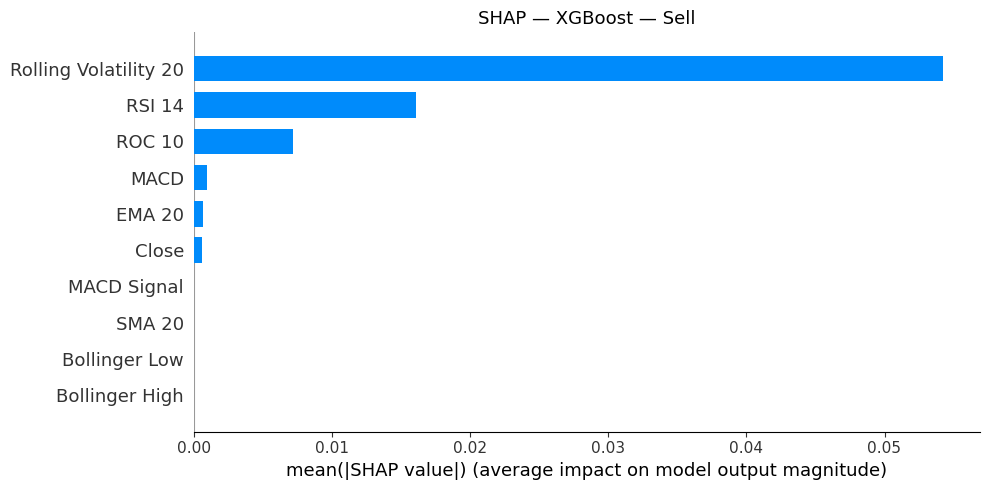

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_1507/3986878530.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


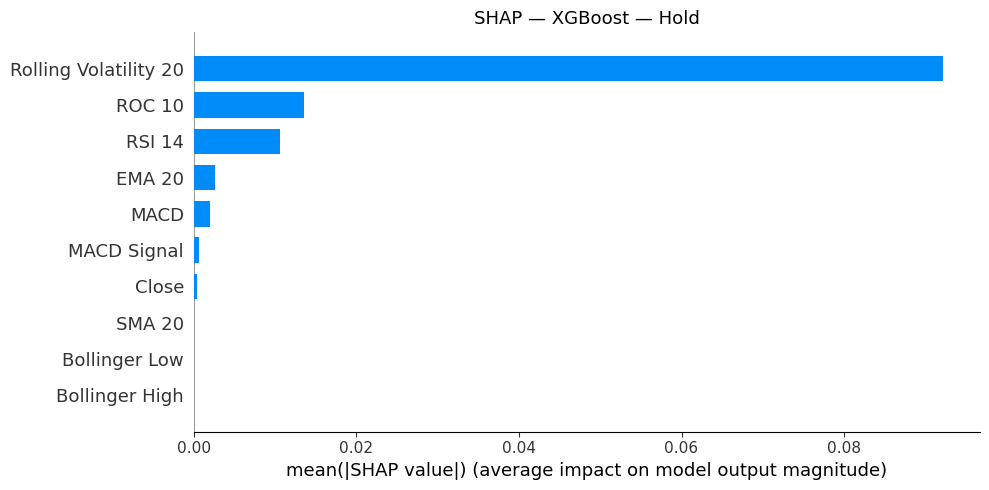

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_1507/3986878530.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


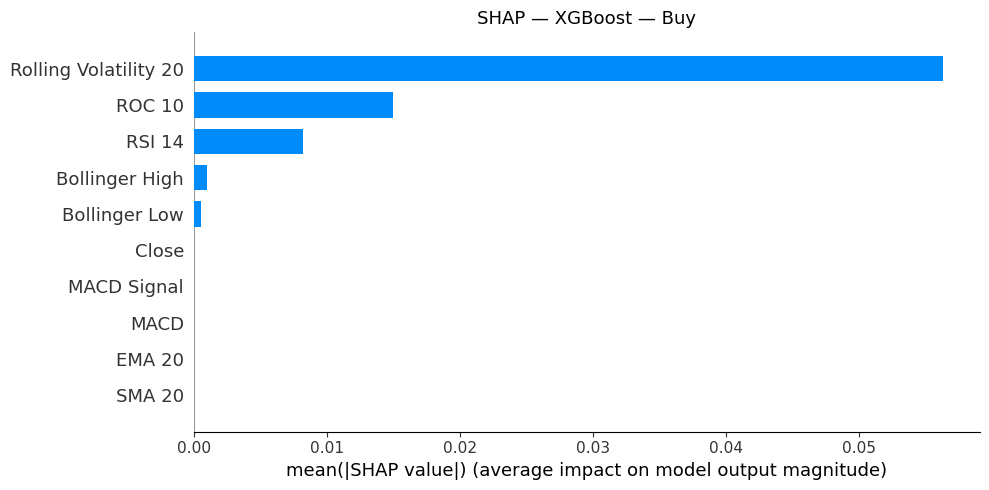


--- Analyse SHAP : Random Forest ---


/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_1507/3986878530.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


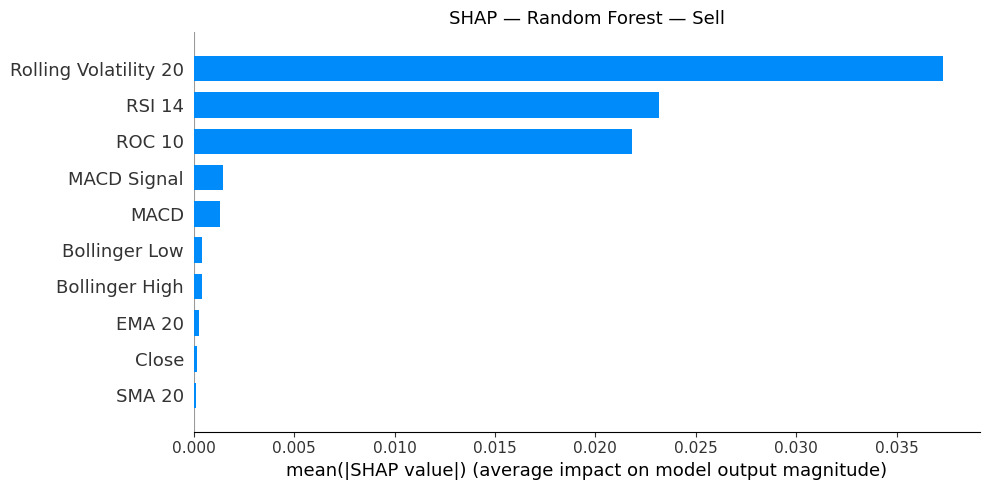

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_1507/3986878530.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


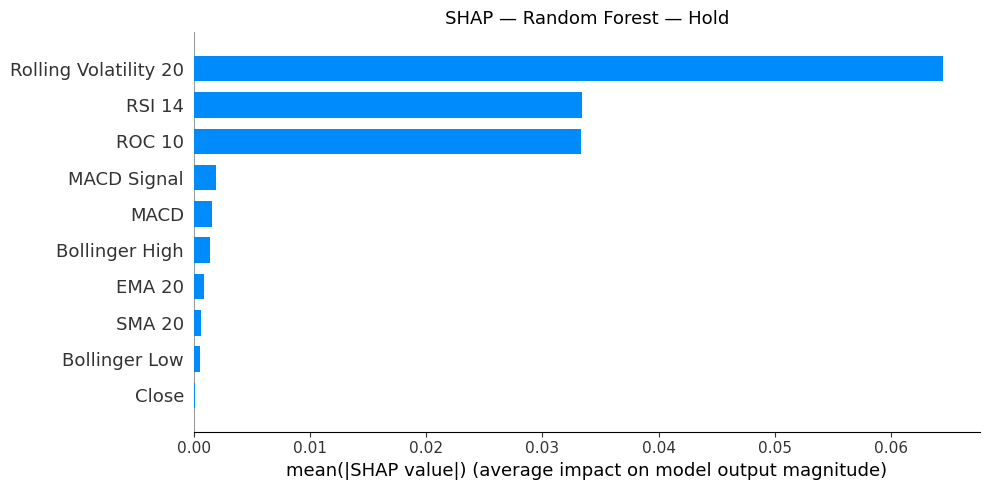

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_1507/3986878530.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


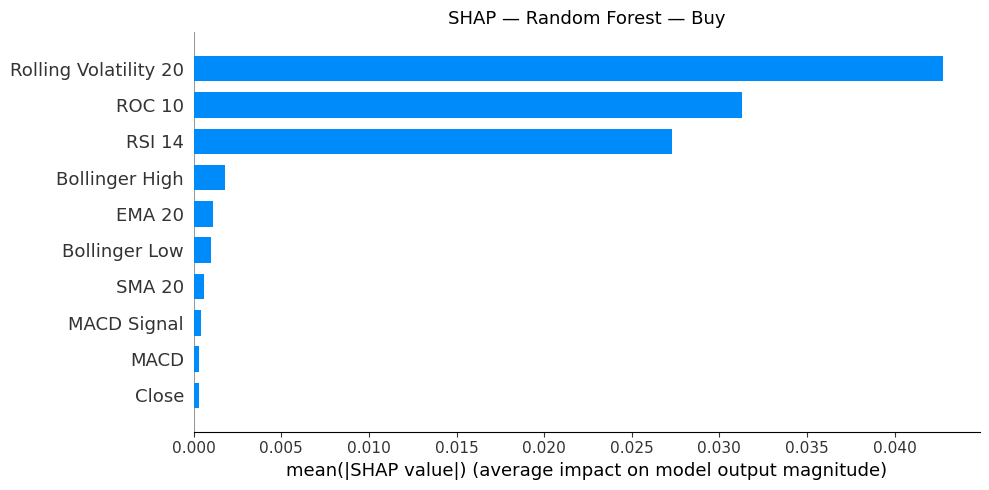

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_1507/3986878530.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



--- Analyse SHAP : KNN ---
  Saut de KNN : incompatible avec SHAP.

--- Analyse SHAP : Logistic Regression ---


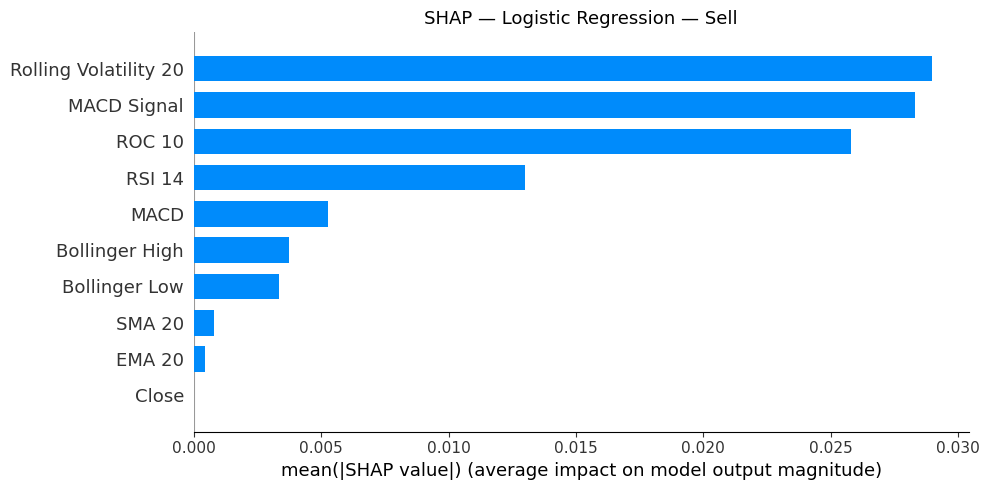

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_1507/3986878530.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


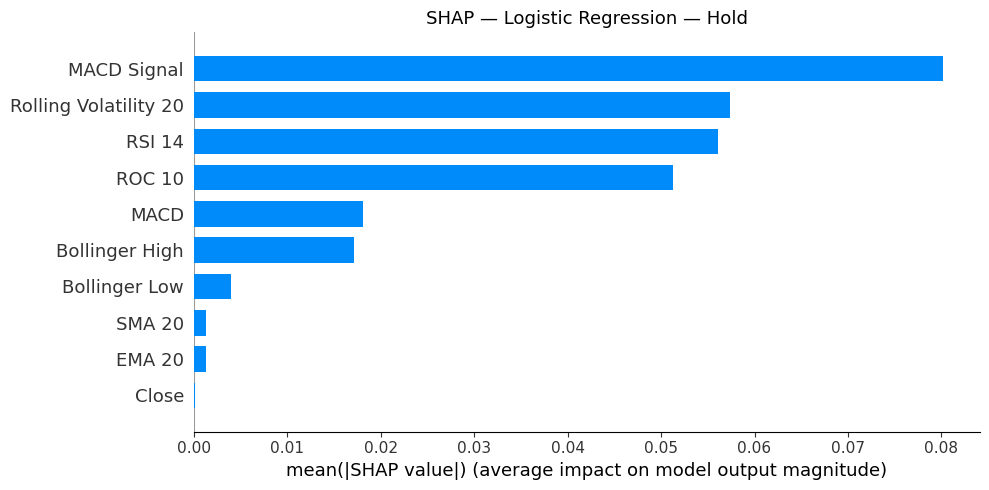

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_1507/3986878530.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


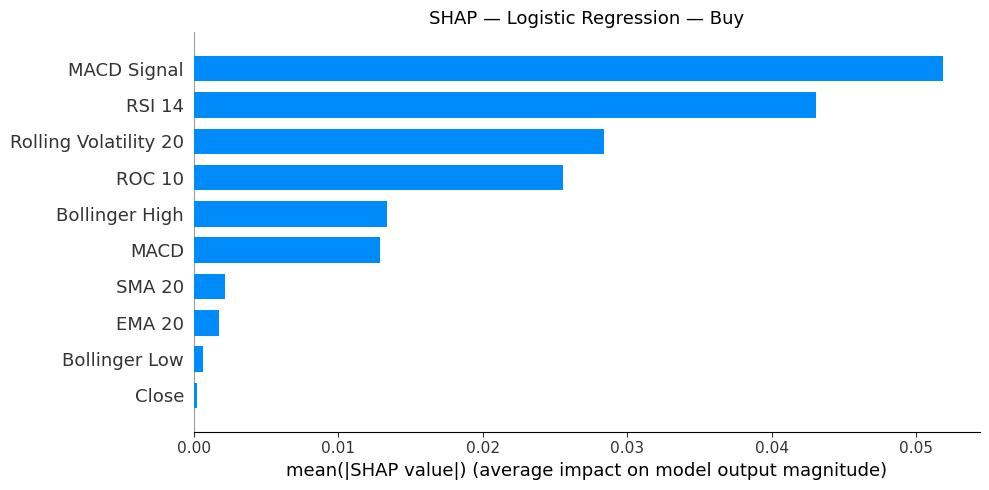


--- Analyse SHAP : SVM ---
  Saut de SVM : incompatible avec SHAP.


In [ ]:
#4. Analyse SHAP
def get_explainer(nom, modele, X_train_df):
    if any(k in nom for k in ["XGBoost", "Random Forest"]):
        return shap.TreeExplainer(modele)
    elif "Logistic Regression" in nom:
        return shap.LinearExplainer(modele, X_train_df)
    else:
        return None  # SVM et KNN ignorés

def analyser_shap(modeles, X_train, X_test, feature_names):
    X_train_df    = pd.DataFrame(X_train, columns=feature_names)
    X_test_df     = pd.DataFrame(X_test,  columns=feature_names)
    n_sample      = min(max(int(len(X_test_df) * 0.1), 50), 200)
    X_test_sample = X_test_df.iloc[:n_sample]
    class_names   = {0: "Sell", 1: "Hold", 2: "Buy"}

    for nom, modele in modeles.items():
        print(f"\n--- Analyse SHAP : {nom} ---")
        explainer = get_explainer(nom, modele, X_train_df)
        if explainer is None:
            print(f"  Saut de {nom} : incompatible avec SHAP.")
            continue

        shap_values = explainer.shap_values(X_test_sample)
        if isinstance(shap_values, list):
            shap_values = np.stack(shap_values, axis=-1)

        for class_idx, class_name in class_names.items():
            sv = shap_values[..., class_idx] if shap_values.ndim == 3 else shap_values
            shap.summary_plot(sv, X_test_sample, plot_type="bar", show=False, plot_size=(10, 5))
            plt.title(f"SHAP — {nom} — {class_name}", fontsize=13)
            plt.tight_layout()
            plt.show()
            plt.close()

analyser_shap(modeles, X_train, X_test, features_names)


In [30]:
#Tableau comparatif des résultats  
def tableau_comparatif(modeles, X_test, y_test):
    resultats = []
    for nom, model in modeles.items():
        y_pred = prediction(model, X_test)   # ← recalculé à chaque itération
        resultats.append({
            "Modèle"            : nom,
            "Accuracy"          : accuracy_score(y_test, y_pred),
            "Precision (Macro)" : precision_score(y_test, y_pred, average='macro', zero_division=0),
            "Recall (Macro)"    : recall_score(y_test, y_pred, average='macro', zero_division=0),
            "F1-Score (Macro)"  : f1_score(y_test, y_pred, average='macro', zero_division=0)
        })
    df_resultats = pd.DataFrame(resultats).sort_values(by="F1-Score (Macro)", ascending=False)
    return df_resultats

df_comparatif = tableau_comparatif(modeles, X_test, y_test)
print(df_comparatif)

                Modèle  Accuracy  Precision (Macro)  Recall (Macro)  \
2                  KNN  0.412372           0.369112        0.366142   
1        Random Forest  0.437380           0.381957        0.371153   
4                  SVM  0.433937           0.382055        0.370464   
0              XGBoost  0.454996           0.378561        0.364882   
3  Logistic Regression  0.459654           0.326386        0.343883   

   F1-Score (Macro)  
2          0.361749  
1          0.359402  
4          0.349473  
0          0.327110  
3          0.239043  


### 1.3 Proposition d'améliorations

A faire

idées de nouvelles vatiables: 
macro : 
 - VIX: quand la volatilité augmente, les actions baissent --> signal: sell

 - Taux 10 ans: quand les taux sont élévées les actions sont moins attractives --> signal: sell

 - SP500 : si le marché monte, l'action a plus de chance de monter

 - Or: valeur refuge, si l'or monte les investisseurs le prefere aux actions

 Temporel: 

 - mois, trimestre (annonce resultat), lundi et vendredi (ouverture et fermeture semaine)